In [1]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import xarray as xr

%matplotlib inline

In [2]:
dataDir='/data/mileshsieh/CMIP6'
m='TaiESM1'
scenarios=['historical','ssp126','ssp245','ssp370','ssp585']

template='%s/%s/%s/atmos/day/r1i1p1f1/%s_day_%s_%s_r1i1p1f1_gn_%04d0101-%04d1231.nc'

var='zg'
p_selected=500 #hpa

/data/mileshsieh/CMIP6/TaiESM1/historical/atmos/day/r1i1p1f1/zg_day_TaiESM1_historical_r1i1p1f1_gn_19900101-19991231.nc


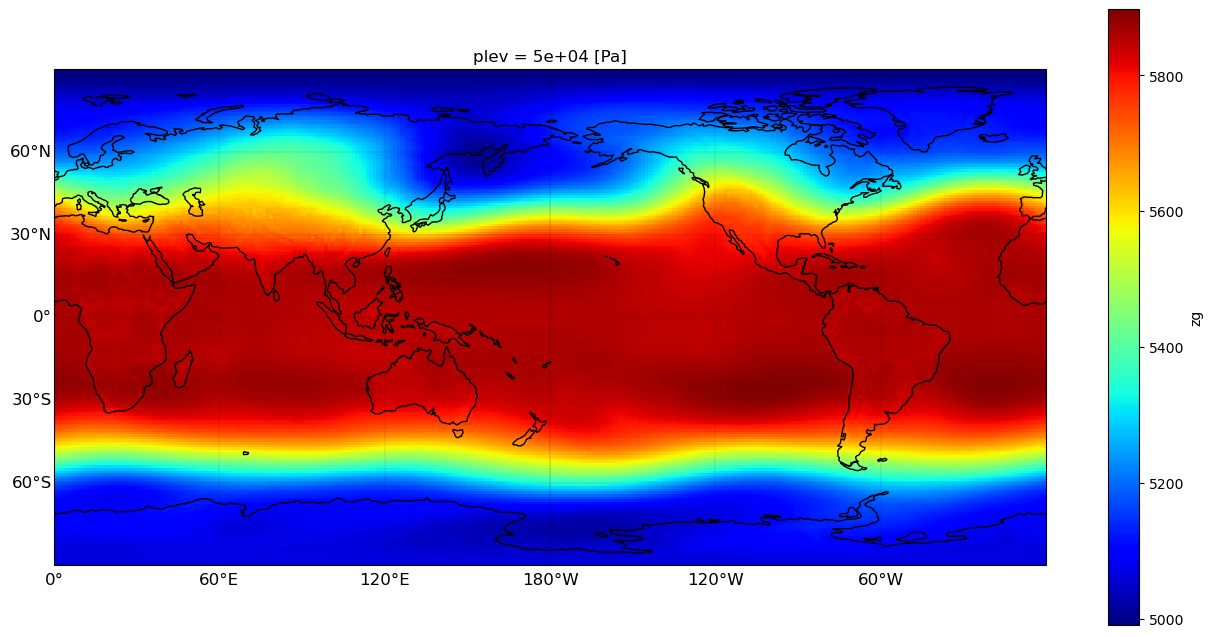

In [3]:
#open single file
yr=1990
sce='historical'
fname=template%(dataDir,m,sce,var,m,sce,yr,yr+9)
print(fname)
ds=xr.open_dataset(fname)
monthly_zg=ds.zg.sel(plev=p_selected*100,time=(ds.time.dt.month == 1))

subplot_kws=dict(projection=ccrs.PlateCarree(central_longitude=180))
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

# Defining the figure
fig = plt.figure(figsize=(16,8), facecolor='w', edgecolor='k')

# Axes with Cartopy projection
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
# and extent
#ax.set_extent([min_lon, max_lon, min_lat, max_lat], 
#              ccrs.PlateCarree(central_longitude=180))

# Plotting using Matplotlib the mean current
cf = monthly_zg.sel(time=(monthly_zg.time.dt.year == 1990)).mean(dim='time').plot( 
     subplot_kws=subplot_kws,transform=ccrs.PlateCarree(), cmap='jet')
ax.coastlines(linewidth=1)
# Plot lat/lon grid 
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.1, color='k', alpha=1, 
                  linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {'size': 12}
gl.ylabel_style = {'size': 12} 

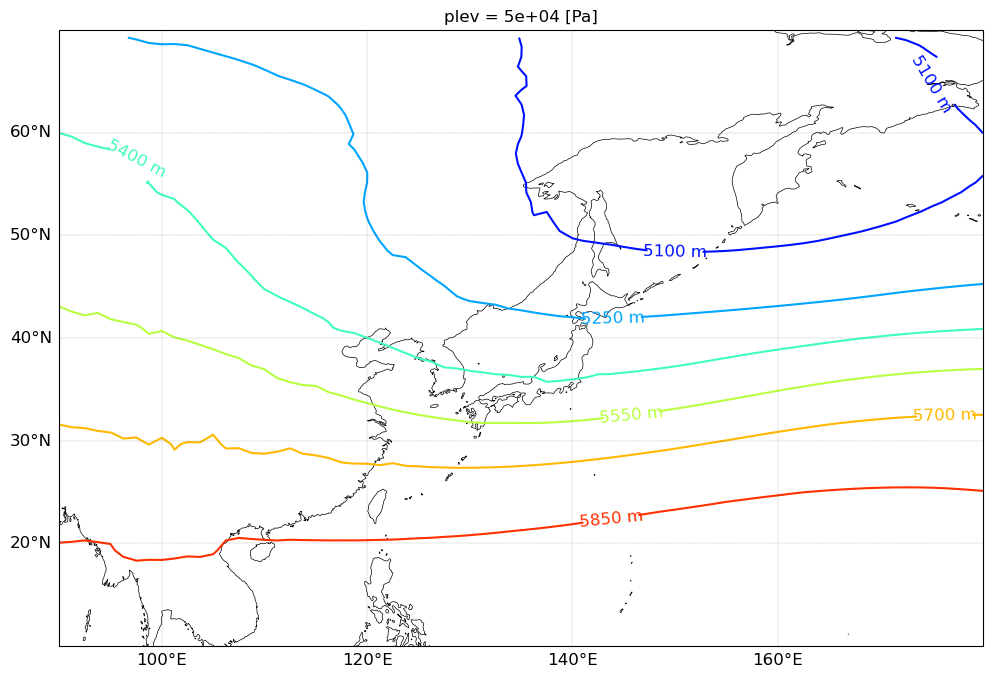

In [4]:
[min_lon, max_lon, min_lat, max_lat]=[90.,180.,10.,70.]
p_selected=500 #hpa
monthly_zg=ds.zg.sel(lat=slice(min_lat,max_lat),lon=slice(min_lon,max_lon),plev=p_selected*100,time=(ds.time.dt.month == 1))

# Defining the figure
fig = plt.figure(figsize=(16,8), facecolor='w', edgecolor='k')

# Axes with Cartopy projection
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
# and extent
ax.set_extent([min_lon, max_lon, min_lat, max_lat], 
              ccrs.PlateCarree())

# Plotting using Matplotlib the mean current
cs = monthly_zg.sel(time=(monthly_zg.time.dt.year == 1990)).mean(dim='time').plot.contour( 
     subplot_kws=subplot_kws,transform=ccrs.PlateCarree(), cmap='jet')
ax.clabel(cs, cs.levels, inline=True, fmt='%.0f m', fontsize=12)
ax.coastlines(resolution='50m',linewidth=0.5)
# Plot lat/lon grid 
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.1, color='k', alpha=1, 
                  linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {'size': 12}
gl.ylabel_style = {'size': 12} 
# Add map features with Cartopy 
#import cartopy.feature as cfeature
#ax.add_feature(cfeature.LAND)
#ax.add_feature(cfeature.OCEAN)
#ax.add_feature(cfeature.COASTLINE)
#ax.add_feature(cfeature.BORDERS, linestyle=':')

In [5]:
#open mfdataset (multiple files dataset)
yrDict={'historical':1990,'ssp585':2075}
h500_monthly={}
for sce in yrDict.keys():
    yr_start=yrDict[sce]

    #open multiple files
    ds=xr.open_mfdataset([template%(dataDir,m,sce,var,m,sce,yr,yr+9) for yr in [yr_start,yr_start+10]])
    #ds["time.month"]
    for mon in [1,2,3,4,10,11,12]:
        h500_monthly['%s_%02d'%(sce,mon)]=ds.zg.sel(lat=slice(min_lat,max_lat),lon=slice(min_lon,max_lon),plev=p_selected*100,time=(ds.time.dt.month == mon))
        

In [6]:
print(h500_monthly.keys())
h500_monthly['historical_03']

dict_keys(['historical_01', 'historical_02', 'historical_03', 'historical_04', 'historical_10', 'historical_11', 'historical_12', 'ssp585_01', 'ssp585_02', 'ssp585_03', 'ssp585_04', 'ssp585_10', 'ssp585_11', 'ssp585_12'])


<xarray.DataArray 'zg' (time: 620, lat: 63, lon: 73)>
dask.array<getitem, shape=(620, 63, 73), dtype=float32, chunksize=(310, 63, 73), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 1990-03-01 12:00:00 ... 2009-03-31 12:00:00
    plev     float64 5e+04
  * lat      (lat) float64 10.84 11.78 12.72 13.66 ... 66.44 67.38 68.32 69.27
  * lon      (lon) float64 90.0 91.25 92.5 93.75 ... 176.2 177.5 178.8 180.0
Attributes:
    standard_name:  geopotential_height
    long_name:      Geopotential Height
    comment:        Geopotential is the sum of the specific gravitational pot...
    units:          m
    original_name:  Z3
    cell_methods:   time: mean
    cell_measures:  area: areacella
    history:        2020-06-12T18:12:54Z altered by CMOR: Converted type from...

1
2
3
4
10
11
12


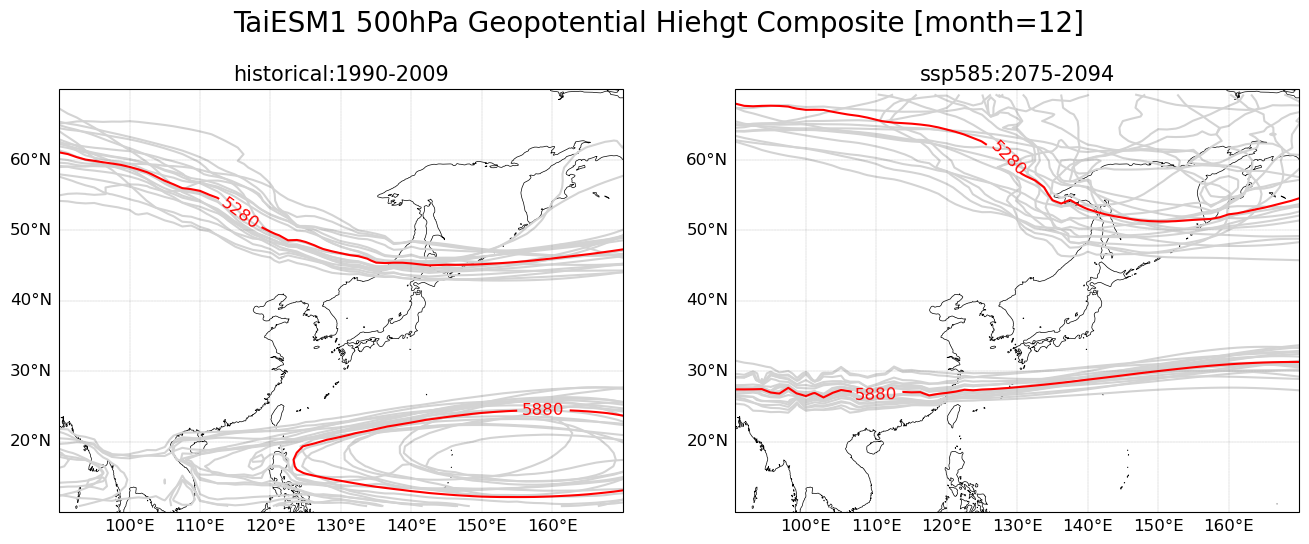

In [15]:
[min_lon, max_lon, min_lat, max_lat]=[90.,170.,10.,70.]
for mon in [1,2,3,4,10,11,12]:
    print(mon)
    plt.close()
    fig,axes = plt.subplots(1, 2,subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)},figsize=(16,6), facecolor='w', edgecolor='k')
    for ax,prd in zip(axes,['historical','ssp585']):
        ax.set_extent([min_lon, max_lon, min_lat, max_lat], ccrs.PlateCarree())
        for yr,grp in h500_monthly['%s_%02d'%(prd,mon)].groupby('time.year'):
            grp.mean(dim='time').plot.contour(ax=ax,transform=ccrs.PlateCarree(), levels=[5280,5880],colors=['lightgray','lightgray'])

        cs=h500_monthly['%s_%02d'%(prd,mon)].mean(dim='time').plot.contour(ax=ax,transform=ccrs.PlateCarree(), levels=[5280,5880],colors=['red','red',])
        ax.clabel(cs, [5280,5880], inline=True, fmt='%.0f', fontsize=12)
        ax.coastlines(resolution='50m',linewidth=0.5)
        ax.set_title('%s:%d-%d'%(prd,yrDict[prd],yrDict[prd]+19),fontsize=15)
        # Plot lat/lon grid 
        gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,linewidth=0.1, color='k', alpha=1, linestyle='--')
        gl.top_labels = False
        gl.right_labels = False
        gl.xformatter = LONGITUDE_FORMATTER
        gl.yformatter = LATITUDE_FORMATTER
        gl.xlabel_style = {'size': 12}
        gl.ylabel_style = {'size': 12} 
    #plt.tight_layout()
    plt.suptitle('TaiESM1 500hPa Geopotential Hiehgt Composite [month=%d]'%mon,fontsize=20)
    plt.savefig('./figures/comp.mon%02d.png'%mon,dpi=300)

    

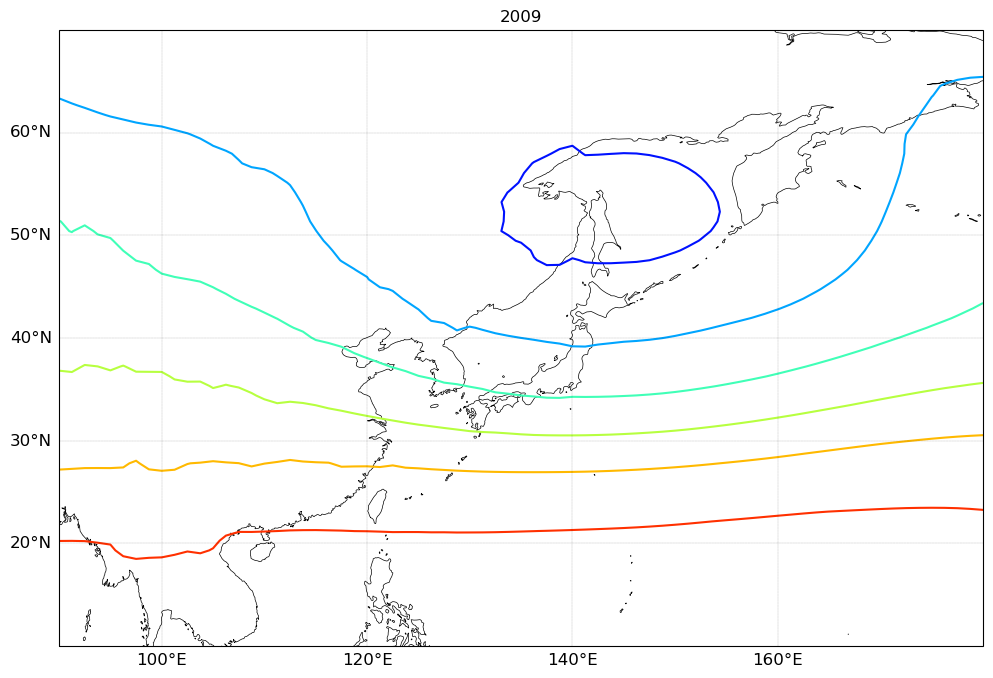

In [13]:
prd='historical'
mon=1

for yr,grp in h500_monthly['%s_%02d'%(prd,mon)].groupby('time.year'):
    plt.close()
    fig=plt.figure(figsize=(16,8), facecolor='w', edgecolor='k')
    ax=plt.subplot(projection=ccrs.PlateCarree(central_longitude=180))
    ax.set_extent([min_lon, max_lon, min_lat, max_lat], ccrs.PlateCarree())
    grp.mean(dim='time').plot.contour(ax=ax,transform=ccrs.PlateCarree(),cmap='jet' )

    ax.coastlines(resolution='50m',linewidth=0.5)
    # Plot lat/lon grid 
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,linewidth=0.1, color='k', alpha=1, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 12}
    gl.ylabel_style = {'size': 12} 
    plt.title('%04d'%yr)
    plt.savefig('%04d_%02d.png'%(yr,mon))